# Iterative Fixer Agent Prompt Training

Train the hybrid pipeline's fixer prompt by iterating on 3 PubTabNet images:
1. **Evaluate** current prompt (TEDS score)
2. **Analyze** cell-level errors on low-scoring images
3. **Meta-prompt** Gemini to suggest an improved fixer prompt
4. **Repeat** until TEDS >= 0.97 or plateau

Then validate best prompt on held-out test images and compare against UniTable-only baseline.

In [1]:
import json
import re
import sys
import random
import base64
import io
import time
from pathlib import Path
from datetime import datetime

import pandas as pd
from PIL import Image
from IPython.display import display, HTML
from bs4 import BeautifulSoup

# Project paths
project_root = Path.cwd().parent
huma_root = project_root / "Huma-Huma"
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if str(huma_root) not in sys.path:
    sys.path.insert(0, str(huma_root))
unitable_repo = huma_root / "unitable"
if str(unitable_repo) not in sys.path:
    sys.path.insert(0, str(unitable_repo))
teds_src = project_root / "pubtabnet" / "src"
if str(teds_src) not in sys.path:
    sys.path.insert(0, str(teds_src))

from metric import TEDS
from shared.client import client, DEFAULT_MODEL

# Config
TRAIN_SIZE = 3
MAX_ITERATIONS = 7
TARGET_TEDS = 0.97
MIN_IMPROVEMENT = 0.005
FIXER_TEMPERATURE = 1.0  # tunable by meta-prompt each iteration

teds_scorer = TEDS(structure_only=False)
teds_structure = TEDS(structure_only=True)

print(f"Model: {DEFAULT_MODEL}")
print(f"Train size: {TRAIN_SIZE}, Max iterations: {MAX_ITERATIONS}, Target TEDS: {TARGET_TEDS}")
print(f"Fixer temperature: {FIXER_TEMPERATURE}")
print("TEDS scorer ready")

Model: gemini-3-flash-preview
Train size: 3, Max iterations: 7, Target TEDS: 0.97
Fixer temperature: 1.0
TEDS scorer ready


## Load PubTabNet ground truth

In [2]:
def format_html_clean(img):
    """Build GT HTML from PubTabNet annotation without prettify whitespace."""
    html_string = '<html><body><table>%s</table></body></html>' % ''.join(img['html']['structure']['tokens'])
    cell_nodes = list(re.finditer(r'(<td[^<>]*>)(</td>)', html_string))
    cells = [''.join(c['tokens']) for c in img['html']['cells']]
    offset = 0
    for n, cell in zip(cell_nodes, cells):
        html_string = html_string[:n.end(1) + offset] + cell + html_string[n.start(2) + offset:]
        offset += len(cell)
    return html_string

gt_path = project_root / "pubtabnet" / "examples" / "PubTabNet_Examples.jsonl"
img_dir = project_root / "pubtabnet" / "examples"

examples = []
with open(gt_path) as f:
    for line in f:
        examples.append(json.loads(line))

gt_data = []
for ex in examples:
    fname = ex["filename"]
    img_path = img_dir / fname
    if img_path.exists():
        gt_data.append({"filename": fname, "image_path": img_path, "gt_html": format_html_clean(ex)})

print(f"Loaded {len(gt_data)} images with ground truth")

Loaded 20 images with ground truth


## Train / test split

In [3]:
random.seed(42)
random.shuffle(gt_data)
train_data = gt_data[:TRAIN_SIZE]
test_data = gt_data[TRAIN_SIZE:TRAIN_SIZE + 3]  # 3 held-out image for now

print(f"Train: {len(train_data)} images")
print(f"  " + ", ".join(d["filename"] for d in train_data))
print(f"Test:  {len(test_data)} images")
print(f"  " + ", ".join(d["filename"] for d in test_data))

Train: 3 images
  PMC5402779_004_00.png, PMC5897438_004_00.png, PMC2759935_007_01.png
Test:  3 images
  PMC2838834_005_00.png, PMC5679144_002_01.png, PMC5577841_001_00.png


## Load UniTable (local MPS)

In [4]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    "unitable_extractor",
    str(huma_root / "table_extraction" / "unitable.py")
)
unitable_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(unitable_mod)

extractor = unitable_mod.UniTableExtractor()  # auto-detects MPS
print(f"UniTable device: {extractor.device}")

Loading UniTable models...
  ✓ Structure model loaded
  ✓ Bbox model loaded
  ✓ Content model loaded
UniTable ready for inference!
UniTable device: mps


## Pre-extract UniTable HTML for all images
Run UniTable once and cache results — deterministic and expensive (~70s/image on MPS).

In [5]:
all_data = train_data + test_data
unitable_cache = {}  # filename → html

for i, item in enumerate(all_data):
    fname = item["filename"]
    print(f"  [{i+1}/{len(all_data)}] UniTable: {fname} ... ", end="", flush=True)
    image = Image.open(item["image_path"]).convert("RGB")
    t0 = time.time()
    try:
        html_out = extractor.extract_html(image)
        elapsed = time.time() - t0
        unitable_cache[fname] = html_out
        print(f"{elapsed:.1f}s")
    except Exception as e:
        print(f"FAILED: {e}")
        unitable_cache[fname] = ""

success = sum(1 for v in unitable_cache.values() if v)
print(f"\nUniTable: {success}/{len(all_data)} extracted and cached")

  [1/6] UniTable: PMC5402779_004_00.png ... 31.3s
  [2/6] UniTable: PMC5897438_004_00.png ... 11.9s
  [3/6] UniTable: PMC2759935_007_01.png ... 95.1s
  [4/6] UniTable: PMC2838834_005_00.png ... 187.6s
  [5/6] UniTable: PMC5679144_002_01.png ... 14.9s
  [6/6] UniTable: PMC5577841_001_00.png ... 27.1s

UniTable: 6/6 extracted and cached


## Hybrid extraction function (parameterized prompt)

In [6]:
def hybrid_extract(image: Image.Image, unitable_html: str, system_prompt: str, temperature: float = 1.0) -> str:
    """Run Gemini fixer with system_instruction separate from HTML input.

    Returns corrected HTML, original unitable_html if NO_CHANGES, or "" on failure.
    """
    if not unitable_html:
        return ""
    buf = io.BytesIO()
    image.save(buf, format="PNG")
    img_bytes = buf.getvalue()

    response = client.models.generate_content(
        model=DEFAULT_MODEL,
        contents=[
            {"inline_data": {"mime_type": "image/png", "data": base64.b64encode(img_bytes).decode()}},
            f"Here is the UniTable HTML to correct:\n\n{unitable_html}",
        ],
        config={"system_instruction": system_prompt, "temperature": temperature},
    )
    text = response.text.strip()

    if text == "NO_CHANGES":
        return unitable_html

    text = re.sub(r'^```html\s*', '', text)
    text = re.sub(r'\s*```$', '', text)
    return text

print("hybrid_extract() ready")

hybrid_extract() ready


## Evaluation function

In [ ]:
def evaluate_prompt(system_prompt: str, temperature: float, data: list, unitable_cache: dict) -> dict:
    """Run hybrid extraction with given system_prompt + temperature on data, return TEDS scores + per-image details."""
    per_image = []
    for item in data:
        fname = item["filename"]
        gt_html = item["gt_html"]
        ut_html = unitable_cache.get(fname, "")
        image = Image.open(item["image_path"]).convert("RGB")

        try:
            pred_html = hybrid_extract(image, ut_html, system_prompt, temperature)
        except Exception as e:
            print(f"  ERROR on {fname}: {e}")
            pred_html = ""

        teds_full = teds_scorer.evaluate(pred_html, gt_html) if pred_html else 0.0
        teds_struct = teds_structure.evaluate(pred_html, gt_html) if pred_html else 0.0

        print(f"  {fname}: TEDS={teds_full:.3f}, Struct={teds_struct:.3f}")

        per_image.append({
            "filename": fname,
            "teds": teds_full,
            "struct_teds": teds_struct,
            "pred_html": pred_html,
            "gt_html": gt_html,
        })

    mean_teds = sum(r["teds"] for r in per_image) / len(per_image) if per_image else 0.0
    mean_struct = sum(r["struct_teds"] for r in per_image) / len(per_image) if per_image else 0.0

    return {
        "mean_teds": mean_teds,
        "mean_struct_teds": mean_struct,
        "per_image": per_image,
    }

print("evaluate_prompt() ready")

evaluate_prompt() ready


## Error analysis function

In [8]:
def analyze_errors(eval_result: dict, threshold: float = 0.97) -> str:
    """Compare pred vs GT HTML for low-TEDS images, extract cell-by-cell text diffs."""
    error_lines = []

    for img_result in eval_result["per_image"]:
        if img_result["teds"] >= threshold:
            continue

        fname = img_result["filename"]
        error_lines.append(f"\n### {fname} (TEDS={img_result['teds']:.3f})")

        pred_soup = BeautifulSoup(img_result["pred_html"], "html.parser")
        gt_soup = BeautifulSoup(img_result["gt_html"], "html.parser")

        pred_cells = [td.get_text(strip=True) for td in pred_soup.find_all("td")]
        gt_cells = [td.get_text(strip=True) for td in gt_soup.find_all("td")]

        # Compare cell counts
        if len(pred_cells) != len(gt_cells):
            error_lines.append(f"  Cell count mismatch: predicted {len(pred_cells)}, ground truth {len(gt_cells)}")

        # Show cell-level diffs (up to 15 per image)
        n_compare = min(len(pred_cells), len(gt_cells))
        diffs_shown = 0
        for i in range(n_compare):
            if pred_cells[i] != gt_cells[i] and diffs_shown < 15:
                error_lines.append(f"  Cell {i}: predicted='{pred_cells[i]}' | gt='{gt_cells[i]}'")
                diffs_shown += 1

        # Show extra/missing cells
        if len(pred_cells) > len(gt_cells):
            for i in range(len(gt_cells), min(len(pred_cells), len(gt_cells) + 5)):
                error_lines.append(f"  Extra cell {i}: '{pred_cells[i]}'")
        elif len(gt_cells) > len(pred_cells):
            for i in range(len(pred_cells), min(len(gt_cells), len(pred_cells) + 5)):
                error_lines.append(f"  Missing cell {i}: gt='{gt_cells[i]}'")

    if not error_lines:
        return "All images meet the TEDS threshold. No errors to report."

    return "\n".join(error_lines)

print("analyze_errors() ready")

analyze_errors() ready


## Meta-prompt + prompt history

In [9]:
from pydantic import BaseModel
from google.genai import types as genai_types

class MetaPromptResponse(BaseModel):
    system_prompt: str
    temperature: float  # suggested fixer temperature for next iteration (0.0–2.0)

META_PROMPT = """You are a prompt engineering expert improving a system prompt for an OCR correction agent.

The agent receives a table image and its UniTable-extracted HTML as a user message, and uses your system prompt to decide whether to correct cell text.

## Current System Prompt
{current_prompt}

## Current Fixer Temperature
{current_temperature}

## Performance
Mean TEDS: {mean_teds:.3f} (target: 0.97+)

## Cell-level errors found
{error_analysis}

## Task
Return an improved system_prompt and a suggested temperature for the fixer agent.

System prompt rules:
- Open with a role statement identifying the agent as an OCR correction expert for HTML tables
- The prompt is a system instruction only — it must NOT contain the HTML itself
- Keep the NO_CHANGES instruction: if no errors are found, agent responds with exactly NO_CHANGES
- Otherwise agent returns only corrected HTML (no markdown fences, no explanations)
- Do NOT change table structure, only cell text content
- Keep the prompt under 400 words
- Focus on fixing the specific error patterns shown above

Temperature guidance:
- Lower temperature (0.0–0.3) for more deterministic, conservative corrections
- Higher temperature (0.7–1.5) if the agent is being too conservative and missing errors
- Suggest a value that addresses the observed error patterns
"""

# Prompt history tracker
prompt_history = []

def record_iteration(iteration, prompt, temperature, eval_result):
    prompt_history.append({
        "iteration": iteration,
        "prompt": prompt,
        "temperature": temperature,
        "mean_teds": eval_result["mean_teds"],
        "mean_struct_teds": eval_result["mean_struct_teds"],
        "prompt_length": len(prompt.split()),
        "timestamp": datetime.now().isoformat(),
    })

def show_history():
    df = pd.DataFrame(prompt_history)
    cols = ["iteration", "mean_teds", "mean_struct_teds", "temperature", "prompt_length", "timestamp"]
    display(df[cols])

print("Meta-prompt and history tracker ready")

Meta-prompt and history tracker ready


## Seed prompt

In [10]:
current_prompt = """You are a meticulous OCR correction expert for HTML tables.

You will receive a table image and the HTML extracted from it by a structure model. The table structure (rows, columns, colspan, rowspan) is correct. Your only job is to fix cell text that doesn't match the image.

If you find no errors, respond with exactly: NO_CHANGES

Otherwise, return only the corrected HTML — no explanations, no markdown fences.

Strict constraints:
- Do NOT modify table structure, HTML tags, or attributes
- Do NOT add or remove cells
- Fix text content only: digits, symbols (±, ≤, ≥, Greek letters), capitalization, subscripts/superscripts
"""

print(f"Seed prompt: {len(current_prompt.split())} words")
print(current_prompt)

Seed prompt: 102 words
You are a meticulous OCR correction expert for HTML tables.

You will receive a table image and the HTML extracted from it by a structure model. The table structure (rows, columns, colspan, rowspan) is correct. Your only job is to fix cell text that doesn't match the image.

If you find no errors, respond with exactly: NO_CHANGES

Otherwise, return only the corrected HTML — no explanations, no markdown fences.

Strict constraints:
- Do NOT modify table structure, HTML tags, or attributes
- Do NOT add or remove cells
- Fix text content only: digits, symbols (±, ≤, ≥, Greek letters), capitalization, subscripts/superscripts



## Training loop

In [11]:
current_temperature = FIXER_TEMPERATURE

for iteration in range(MAX_ITERATIONS):
    print(f"\n{'='*70}")
    print(f"ITERATION {iteration}  (temperature={current_temperature})")
    print(f"{'='*70}")

    # 1. Evaluate current prompt on train set
    print(f"\nEvaluating prompt ({len(current_prompt.split())} words)...")
    eval_result = evaluate_prompt(current_prompt, current_temperature, train_data, unitable_cache)
    mean_teds = eval_result["mean_teds"]
    print(f"\n  Mean TEDS: {mean_teds:.3f} | Mean Struct: {eval_result['mean_struct_teds']:.3f}")

    # 2. Record
    record_iteration(iteration, current_prompt, current_temperature, eval_result)

    # 3. Check stopping: target met
    if mean_teds >= TARGET_TEDS:
        print(f"\n  TARGET REACHED ({mean_teds:.3f} >= {TARGET_TEDS}). Stopping.")
        break

    # 4. Check plateau
    if iteration > 0:
        prev_teds = prompt_history[-2]["mean_teds"]
        delta = mean_teds - prev_teds
        print(f"  Delta from previous: {delta:+.4f}")
        if delta < MIN_IMPROVEMENT:
            print(f"\n  PLATEAU (delta {delta:.4f} < {MIN_IMPROVEMENT}). Stopping.")
            break

    # 5. Analyze errors
    print("\nAnalyzing errors...")
    error_analysis = analyze_errors(eval_result)
    print(error_analysis[:500])

    # 6. Call Gemini meta-prompt with structured output
    print("\nGenerating improved system prompt via meta-prompt...")
    meta_filled = META_PROMPT.format(
        current_prompt=current_prompt,
        current_temperature=current_temperature,
        mean_teds=mean_teds,
        error_analysis=error_analysis,
    )
    response = client.models.generate_content(
        model=DEFAULT_MODEL,
        contents=[meta_filled],
        config=genai_types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=MetaPromptResponse,
        ),
    )
    meta_result = MetaPromptResponse.model_validate_json(response.text)
    current_prompt = meta_result.system_prompt
    current_temperature = round(max(0.0, min(2.0, meta_result.temperature)), 2)

    print(f"  New prompt: {len(current_prompt.split())} words | New temperature: {current_temperature}")

print(f"\n{'='*70}")
print("TRAINING COMPLETE")
print(f"{'='*70}")
show_history()


ITERATION 0  (temperature=1.0)

Evaluating prompt (102 words)...
  PMC5402779_004_00.png: TEDS=0.956, Struct=1.000
  PMC5897438_004_00.png: TEDS=0.994, Struct=1.000
  PMC2759935_007_01.png: TEDS=0.822, Struct=1.000

  Mean TEDS: 0.924 | Mean Struct: 1.000

Analyzing errors...

### PMC5402779_004_00.png (TEDS=0.956)

### PMC2759935_007_01.png (TEDS=0.822)

Generating improved system prompt via meta-prompt...
  New prompt: 111 words | New temperature: 0.1

ITERATION 1  (temperature=0.1)

Evaluating prompt (111 words)...
  PMC5402779_004_00.png: TEDS=0.000, Struct=0.000
  PMC5897438_004_00.png: TEDS=0.994, Struct=1.000
  PMC2759935_007_01.png: TEDS=0.822, Struct=1.000

  Mean TEDS: 0.605 | Mean Struct: 0.667
  Delta from previous: -0.3188

  PLATEAU (delta -0.3188 < 0.005). Stopping.

TRAINING COMPLETE


,iteration,mean_teds,mean_struct_teds,temperature,prompt_length,timestamp
0,0,0.924125,1.000000,1.0,102,2026-03-16T10:55:26.259427
1,1,0.605329,0.666667,0.1,111,2026-03-16T11:10:27.782377


## Prompt evolution display

In [12]:
for entry in prompt_history:
    print(f"\n{'='*70}")
    print(f"Iteration {entry['iteration']} | TEDS: {entry['mean_teds']:.3f} | Words: {entry['prompt_length']}")
    print(f"{'='*70}")
    print(entry["prompt"][:600])
    if len(entry["prompt"]) > 600:
        print("...")


Iteration 0 | TEDS: 0.924 | Words: 102
You are a meticulous OCR correction expert for HTML tables.

You will receive a table image and the HTML extracted from it by a structure model. The table structure (rows, columns, colspan, rowspan) is correct. Your only job is to fix cell text that doesn't match the image.

If you find no errors, respond with exactly: NO_CHANGES

Otherwise, return only the corrected HTML — no explanations, no markdown fences.

Strict constraints:
- Do NOT modify table structure, HTML tags, or attributes
- Do NOT add or remove cells
- Fix text content only: digits, symbols (±, ≤, ≥, Greek letters), capitalizat
...

Iteration 1 | TEDS: 0.605 | Words: 111
You are a meticulous OCR correction expert for HTML tables. Your task is to compare the provided table image with its extracted HTML code. The table structure (rows, columns, colspan, rowspan) is guaranteed to be correct. Your sole responsibility is to identify and fix any cell text errors. Focus intensively on ma

## Validate best prompt on held-out test set

In [13]:
# Pick the best prompt from training
best_entry = max(prompt_history, key=lambda x: x["mean_teds"])
best_prompt = best_entry["prompt"]
print(f"Best prompt from iteration {best_entry['iteration']} (train TEDS: {best_entry['mean_teds']:.3f})")

# Evaluate on held-out test set
print(f"\nValidating on {len(test_data)} test images...")
test_result = evaluate_prompt(best_prompt, test_data, unitable_cache)

print(f"\n{'='*60}")
print(f"TEST SET RESULTS")
print(f"{'='*60}")
print(f"  Mean TEDS:      {test_result['mean_teds']:.3f}")
print(f"  Mean Struct:    {test_result['mean_struct_teds']:.3f}")
print(f"  Train TEDS:     {best_entry['mean_teds']:.3f}")
print(f"  Generalization: {'PASS' if test_result['mean_teds'] >= TARGET_TEDS else 'BELOW TARGET'}")

Best prompt from iteration 0 (train TEDS: 0.924)

Validating on 3 test images...


TypeError: evaluate_prompt() missing 1 required positional argument: 'unitable_cache'

## Baseline comparison: UniTable-only vs best hybrid

In [ ]:
# Score UniTable-only (no Gemini fixer) against GT on test set
rows = []
for item in test_data:
    fname = item["filename"]
    gt_html = item["gt_html"]
    ut_html = unitable_cache.get(fname, "")

    ut_teds = teds_scorer.evaluate(ut_html, gt_html) if ut_html else 0.0
    ut_struct = teds_structure.evaluate(ut_html, gt_html) if ut_html else 0.0

    # Find hybrid result from test_result
    hybrid_entry = next((r for r in test_result["per_image"] if r["filename"] == fname), None)
    hy_teds = hybrid_entry["teds"] if hybrid_entry else 0.0
    hy_struct = hybrid_entry["struct_teds"] if hybrid_entry else 0.0

    rows.append({
        "filename": fname,
        "UniTable TEDS": round(ut_teds, 3),
        "UniTable Struct": round(ut_struct, 3),
        "Hybrid TEDS": round(hy_teds, 3),
        "Hybrid Struct": round(hy_struct, 3),
        "Delta": round(hy_teds - ut_teds, 3),
    })

df_compare = pd.DataFrame(rows)
display(df_compare)

# Aggregates
ut_mean = df_compare["UniTable TEDS"].mean()
hy_mean = df_compare["Hybrid TEDS"].mean()
print(f"\nTest set aggregates:")
print(f"  UniTable-only:  {ut_mean:.3f} mean TEDS")
print(f"  Best hybrid:    {hy_mean:.3f} mean TEDS")
print(f"  Improvement:    {hy_mean - ut_mean:+.3f}")

,filename,UniTable TEDS,UniTable Struct,Hybrid TEDS,Hybrid Struct,Delta
0,PMC2838834_005_00.png,0.947,1.0,0.992,1.0,0.046
1,PMC5679144_002_01.png,0.929,1.0,0.990,1.0,0.061
2,PMC5577841_001_00.png,0.931,1.0,0.973,1.0,0.042



Test set aggregates:
  UniTable-only:  0.936 mean TEDS
  Best hybrid:    0.985 mean TEDS
  Improvement:    +0.049


## Summary chart: TEDS per iteration

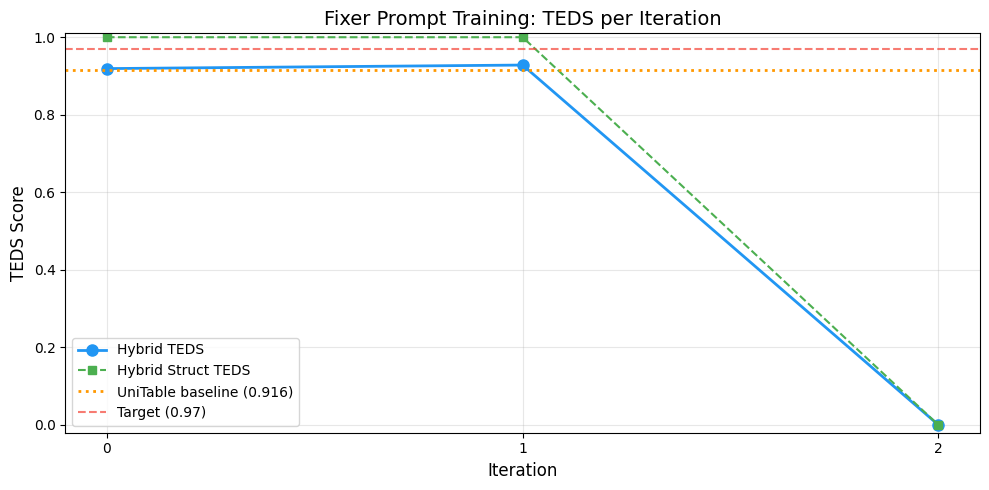

In [ ]:
import matplotlib.pyplot as plt

iterations = [e["iteration"] for e in prompt_history]
teds_scores = [e["mean_teds"] for e in prompt_history]
struct_scores = [e["mean_struct_teds"] for e in prompt_history]

# UniTable baseline on train set
ut_baseline_scores = []
for item in train_data:
    ut_html = unitable_cache.get(item["filename"], "")
    score = teds_scorer.evaluate(ut_html, item["gt_html"]) if ut_html else 0.0
    ut_baseline_scores.append(score)
ut_baseline = sum(ut_baseline_scores) / len(ut_baseline_scores)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(iterations, teds_scores, 'o-', color='#2196F3', linewidth=2, markersize=8, label='Hybrid TEDS')
ax.plot(iterations, struct_scores, 's--', color='#4CAF50', linewidth=1.5, markersize=6, label='Hybrid Struct TEDS')
ax.axhline(y=ut_baseline, color='#FF9800', linestyle=':', linewidth=2, label=f'UniTable baseline ({ut_baseline:.3f})')
ax.axhline(y=TARGET_TEDS, color='#F44336', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Target ({TARGET_TEDS})')

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('TEDS Score', fontsize=12)
ax.set_title('Fixer Prompt Training: TEDS per Iteration', fontsize=14)
ax.legend(fontsize=10)
ax.set_ylim(min(min(teds_scores), ut_baseline) - 0.02, 1.01)
ax.set_xticks(iterations)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Export best prompt

In [ ]:
print("="*70)
print("BEST FIXER PROMPT")
print(f"From iteration {best_entry['iteration']} | Train TEDS: {best_entry['mean_teds']:.3f} | Test TEDS: {test_result['mean_teds']:.3f}")
print("="*70)
print()
print(best_prompt)

BEST FIXER PROMPT
From iteration 1 | Train TEDS: 0.928 | Test TEDS: 0.985

You are a meticulous data verification expert. I have provided an image of a table and its corresponding HTML representation generated by an OCR model. The table structure (rows, columns, and spans) is 100% correct, but the text within cells contains OCR inaccuracies.

Your task: Correct the text content of every cell by comparing the provided HTML to the original image. 

Pay close attention to these high-error areas:
1. **Mathematical & Scientific Symbols:** Ensure symbols like ±, <, >, ≤, ≥, and Greek letters (α, β, γ) are accurately captured.
2. **Numeric Precision:** Check every digit. Pay special attention to decimal points and commas. Differentiate clearly between '0' (zero) and 'O' (capital o), and '1' (one) vs 'l' (lowercase L) or 'I' (capital i).
3. **Case Sensitivity & Formatting:** Maintain the exact capitalization of headers and data entries. 
4. **Subscripts/Superscripts:** If the image shows chemi